# First approach to a quantum code of a linear regression.

### Step 1: Synthetic Data Generation

In this step, we create two groups of points (A and B) centered on different coordinates. This serves as "training" for the model to learn to distinguish between them.

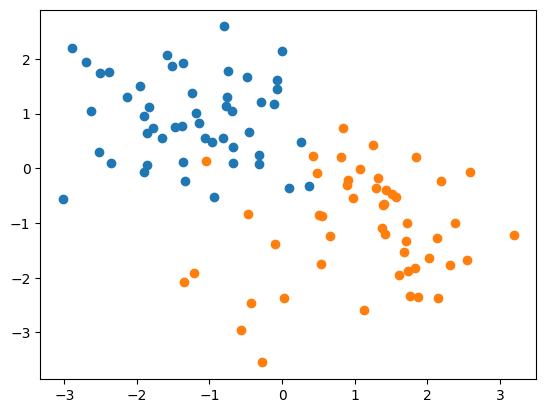

In [1]:
#===================================
#Libreria
#===================================
import pennylane as qml
from pennylane import numpy as np 
import matplotlib.pyplot as plt

#================================================================
# Generación de 100 puntos aleatorios (50 en cada grupo)
n_samples = 100
# Grupo A centrado en (-1, 1) y Grupo B centrado en (1, -1)
A = np.array([[np.random.normal(loc=-1), np.random.normal(loc=1)] for i in range(n_samples//2)]) 
B = np.array([[np.random.normal(loc=1), np.random.normal(loc=-1)] for i in range(n_samples//2)]) 

# Visualización inicial de los grupos
plt.scatter(A[:,0], A[:,1])
plt.scatter(B[:,0], B[:,1])
plt.show()

### Step 2: Dataset Preparation

We label the points with -1 and 1 to prepare a supervised binary classification problem.

In [2]:
# Concatenar características (puntos) y etiquetas (-1 y 1)
feature = np.concatenate([A, B], axis=0)
label = np.concatenate([-np.ones(n_samples // 2), np.ones(n_samples//2)], axis=0)
data = list(zip(feature, label))

### Step 3: Model Definition and Visualization Functions

Here we define the model function, which acts as a classifier (a kind of classic "neuron" that uses arctan for normalization). We also prepare the functions to draw the line separating the points.

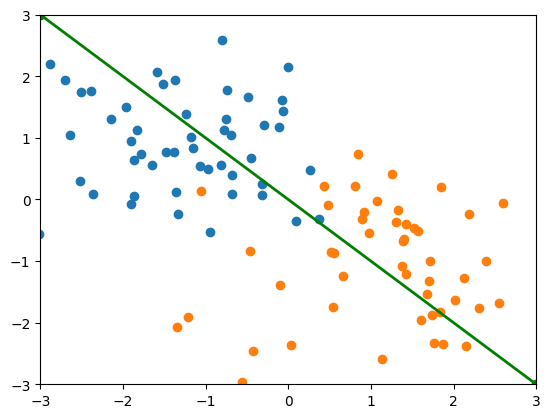

In [3]:
def model(x, w):
    # Función de activación arcotangente normalizada
    return np.arctan(x[0]*w[0] + x[1]*w[1] + w[2]) / (np.pi / 2)

w = np.array([1, 1, 0], requires_grad = True)

def img_line(x, w):
    # Calcula la posición Y para dibujar la recta de separación
    if w[1] == 0:
        w[1] = 0.0001
    return -(w[0] * x + w[2]) / w[1]

def plot_model(w):
    x1, x2 = -3, 3
    plt.plot([x1, x2], [img_line(x1,w), img_line(x2,w)], 'go-', label='line 1', linewidth=2)
    plt.scatter(A[:,0], A[:,1])
    plt.scatter(B[:,0], B[:,1])
    plt.axis((-3,3,-3,3))
    plt.show()

# Mostrar la línea inicial (antes del entrenamiento)
plot_model(w)

### Step 4: Defining the Loss Function

The loss function quantifies how poorly the model is performing. Here, we calculate the mean squared error relative to the actual labels.

In [4]:
def average_loss(w, data):
    losses = 0
    for x, y in data:
        losses += (model(x, w) - y) ** 2
    return losses / len(data)

# Prueba inicial del error
print(average_loss([1, 1, 0], data))

1.0248122346476616


### Step 5: Training (Gradient Descent)

We use qml.grad to calculate the derivative of the loss with respect to the weights w and update them iteratively so that the line better separates the points.

epoch 100 loss 0.16959623047961273


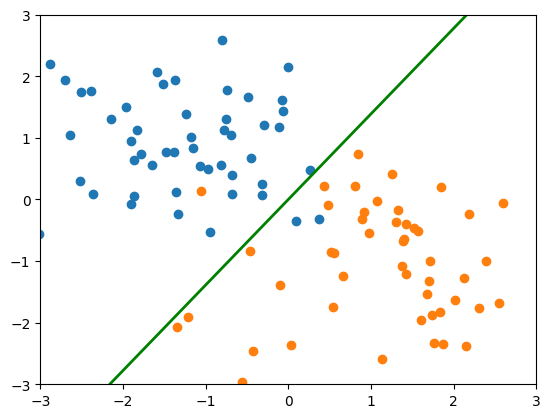

In [5]:
from IPython.display import clear_output
w = np.array([1, 1, 0], requires_grad = True)
lr = 0.1 # Tasa de aprendizaje

for epoch in range(101):
    # Actualización de pesos usando gradiente
    w = w - lr * qml.grad(average_loss, argnum=0)(w, data)
    
    if epoch % 5 == 0:
        print("epoch", epoch, "loss", average_loss(w, data))
        plot_model(w) # Visualización de cómo se ajusta la recta
        clear_output(wait=True)